Visualize spectrograms of trimmed audio

Found 112 total files
Visualizing: SL54 Trial 1_trim.WAV

Processing: SL54 Trial 1_trim.WAV
  Duration: 5.00 seconds
  ✓ Spectrogram created successfully


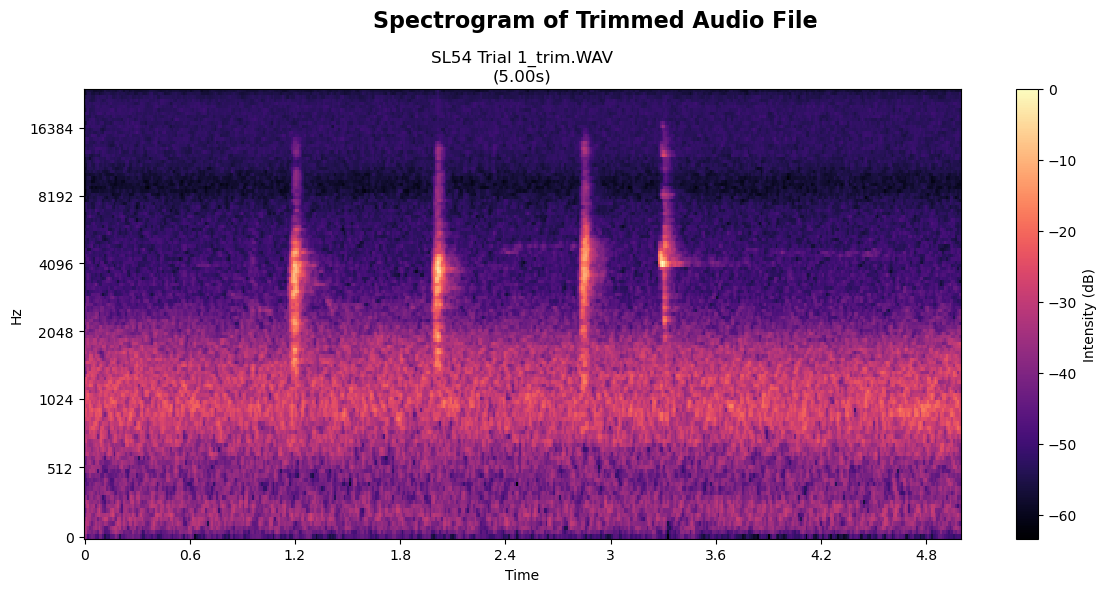


=== Spectrogram visualization complete! ===
Look at the spectrogram above to see:
  - Time on the X-axis (should be ~60 seconds)
  - Frequency on the Y-axis (how high/low the sounds are)
  - Color intensity (brighter = louder/more energy)


In [4]:
# === VISUALIZE SPECTROGRAMS FROM TRIMMED AUDIO ===
# This code will load a few audio files and display their spectrograms
# A spectrogram is a visual representation of sound over time
# It shows frequency (how high/low the sound is) on the y-axis and time on the x-axis

import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# === SET UP ===
# Tell Python where our trimmed audio files are
trimmed_audio_dir = "/mnt/class_data/Shelby/One_Minute_Audio"

# Get a list of audio files to visualize
# We'll just look at the first file
audio_files = [f for f in os.listdir(trimmed_audio_dir) if f.endswith('.WAV') or f.endswith('.wav')]
file_to_visualize = audio_files[2]  # Take only the first file

print(f"Found {len(audio_files)} total files")
print(f"Visualizing: {file_to_visualize}")

# === CREATE SPECTROGRAM ===
# Create a single plot to show one spectrogram
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Spectrogram of Trimmed Audio File', fontsize=16, fontweight='bold')

# Process the audio file
print(f"\nProcessing: {file_to_visualize}")

try:
    # Create the full path to the audio file
    audio_path = os.path.join(trimmed_audio_dir, file_to_visualize)
    
    # Load the audio file
    # y = the audio data (sound waves as numbers)
    # sr = sample rate (how many samples per second, usually 44100 or 256000)
    y, sr = librosa.load(audio_path, sr=None)

        # Trim to first 5 seconds
    duration_limit = 5  # seconds
    samples_to_keep = sr * duration_limit
    y = y[:int(samples_to_keep)]
    
    # Calculate how long the audio is in seconds
    duration = librosa.get_duration(y=y, sr=sr)
    print(f"  Duration: {duration:.2f} seconds")
    
    # Create a spectrogram from the audio
    # A spectrogram breaks the audio into tiny pieces and analyzes each piece
    # S = spectrogram (magnitude of frequencies over time)
    # S_db = spectrogram in decibels (a better scale for human hearing)
    S = librosa.feature.melspectrogram(y=y, sr=sr)
    S_db = librosa.power_to_db(S, ref=np.max)
    
    # Display the spectrogram on the plot
    img = librosa.display.specshow(
        S_db,
        sr=sr,
        ax=ax,
        x_axis='time',  # Show time on x-axis
        y_axis='mel'    # Show frequency (mel scale) on y-axis
    )
    
    # Add a label and title to the plot
    ax.set_title(f'{file_to_visualize}\n({duration:.2f}s)', fontsize=12)
    
    # Add a colorbar to show what the colors mean (intensity of sound)
    plt.colorbar(img, ax=ax, label='Intensity (dB)')
    
    print(f"  ✓ Spectrogram created successfully")
    
except Exception as e:
    print(f"  ✗ Error creating spectrogram: {str(e)}")
    ax.text(0.5, 0.5, f'Error: {str(e)}', ha='center', va='center')

# Adjust the layout so nothing overlaps
plt.tight_layout()

# Display the plot
plt.show()

print("\n=== Spectrogram visualization complete! ===")
print("Look at the spectrogram above to see:")
print("  - Time on the X-axis (should be ~60 seconds)")
print("  - Frequency on the Y-axis (how high/low the sounds are)")
print("  - Color intensity (brighter = louder/more energy)")


Draw bounding boxes- Raven matched

Loaded 6238 annotations from CSV

Looking for: RC02 Trial 1_trim.WAV
Exact match for 'RC02 Trial 1_trim.WAV': 71 annotations
Audio duration: 5.00 seconds
Sample rate: 48000 Hz

Spectrogram axis limits after display:
  X-axis (time): (np.float64(-0.0026666666666666666), np.float64(4.989333333333333))
  Y-axis (Hz): (np.float64(2000.0), np.float64(8000.0))

Drawing 2 bounding boxes...


All annotations min/max:
  Time (seconds): 1.20 - 4.73
  Freq (Hz): 2000 - 8000
Annotation 1:
  Time: 1.20-1.26s
  Freq (Hz): 2000-8000
Annotation 2:
  Time: 4.66-4.73s
  Freq (Hz): 2000-8000

Added 2 rectangles to the plot
Saved spectrogram PNG to: RC02 Trial 1_trim_spec_1280x720.png
✓ Spectrogram with 2 annotations created successfully


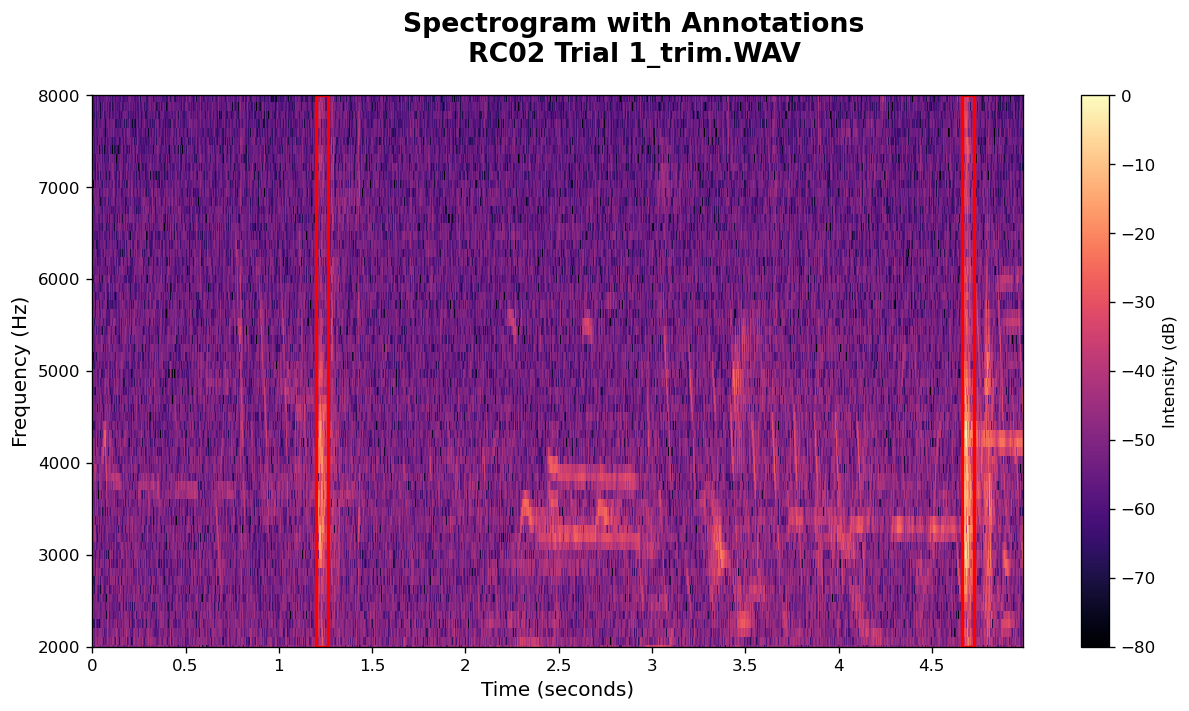


=== Visualization complete! ===


In [3]:
# === VISUALIZE SPECTROGRAMS WITH BOUNDING BOXES FROM CSV ANNOTATIONS ===
# Raven-matched STFT settings + crisper rendering + fixed pixel output for YOLO-like clarity.
#
# Changes vs your current cell:
# - Keep true "zoom quality": we recompute STFT from the 5s audio (same as before).
# - Render without smoothing: shading="nearest", antialiased=False.
# - Use ONE frequency zoom method: ax.set_ylim(2000, 8000) (removed fmin/fmax from specshow).
# - Fixed pixel size output (useful for YOLO): set figsize from desired pixels + dpi.
# - Save a PNG at exactly that resolution so you can compare vs VS Code inline display.

import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import librosa
import librosa.display

# === LOAD THE CSV FILE ===
csv_path = "/home/Shelby/blackbird_calls/Dataset_processing/Datasets/cv4e_calls_channel1.csv"
annotations_df = pd.read_csv(csv_path)
print(f"Loaded {len(annotations_df)} annotations from CSV")

current_wav_fname = file_to_visualize
print(f"\nLooking for: {current_wav_fname}")

matching_annotations = annotations_df[annotations_df["wav_fname"] == current_wav_fname]
print(f"Exact match for '{current_wav_fname}': {len(matching_annotations)} annotations")

if len(matching_annotations) == 0:
    print("\nNo exact match found. Trying case-insensitive match...")
    matching_annotations = annotations_df[annotations_df["wav_fname"].str.lower() == current_wav_fname.lower()]
    print(f"Case-insensitive match: {len(matching_annotations)} annotations")

if len(matching_annotations) == 0:
    print("\nWARNING: Still no annotations found!")
else:
    # --- Fixed pixel sizing (helps avoid VS Code scaling blur and matches YOLO expectations) ---
    img_w_px, img_h_px = 1280, 720
    dpi = 120
    fig, ax = plt.subplots(figsize=(img_w_px / dpi, img_h_px / dpi), dpi=dpi)

    fig.suptitle(f"Spectrogram with Annotations\n{file_to_visualize}", fontsize=16, fontweight="bold")

    try:
        audio_path = os.path.join(trimmed_audio_dir, file_to_visualize)

        # Load audio without resampling; use channel 1 only if stereo
        y, sr = librosa.load(audio_path, sr=None, mono=False)
        if y.ndim > 1:
            y = y[0]

        # Trim to first 5 seconds
        duration_limit = 5
        y = y[: int(sr * duration_limit)]

        duration = librosa.get_duration(y=y, sr=sr)
        print(f"Audio duration: {duration:.2f} seconds")
        print(f"Sample rate: {sr} Hz\n")

        # --- Raven-matched STFT settings ---
        n_fft = 512
        win_length = 512
        hop_length = 256
        window = "hann"

        D = librosa.stft(
            y,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=win_length,
            window=window,
            center=False,
        )
        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

        # --- Display: crisp bin rendering (no smoothing) ---
        img = librosa.display.specshow(
            S_db,
            sr=sr,
            hop_length=hop_length,
            ax=ax,
            x_axis="time",
            y_axis="linear",
            shading="nearest",
            antialiased=False,
        )

        # --- Frequency zoom (use only ONE method for clarity) ---
        ax.set_ylim(2000, 8000)

        print("Spectrogram axis limits after display:")
        print(f"  X-axis (time): {ax.get_xlim()}")
        print(f"  Y-axis (Hz): {ax.get_ylim()}\n")

        time_max = duration_limit
        matching_annotations = matching_annotations[
            matching_annotations["begin_time_s"] < time_max
        ].copy()
        matching_annotations["end_time_s"] = matching_annotations["end_time_s"].clip(upper=time_max)

        f_lo, f_hi = 2000, 8000
        matching_annotations = matching_annotations[
            (matching_annotations["high_freq_hz"] > f_lo) & (matching_annotations["low_freq_hz"] < f_hi)
        ].copy()
        matching_annotations["low_freq_hz"] = matching_annotations["low_freq_hz"].clip(lower=f_lo)
        matching_annotations["high_freq_hz"] = matching_annotations["high_freq_hz"].clip(upper=f_hi)

        # === DRAW BOUNDING BOXES FROM ANNOTATIONS ===
        print(f"Drawing {len(matching_annotations)} bounding boxes...\n")
        print("\nAll annotations min/max:")
        print(f"  Time (seconds): {matching_annotations['begin_time_s'].min():.2f} - {matching_annotations['end_time_s'].max():.2f}")
        print(f"  Freq (Hz): {matching_annotations['low_freq_hz'].min():.0f} - {matching_annotations['high_freq_hz'].max():.0f}")

        box_count = 0
        for idx, (_, row) in enumerate(matching_annotations.iterrows()):
            time_start = float(row["begin_time_s"])
            time_end = float(row["end_time_s"])
            freq_low_hz = float(row["low_freq_hz"])
            freq_high_hz = float(row["high_freq_hz"])

            if idx < 10:
                print(f"Annotation {idx + 1}:")
                print(f"  Time: {time_start:.2f}-{time_end:.2f}s")
                print(f"  Freq (Hz): {freq_low_hz:.0f}-{freq_high_hz:.0f}")

            rect = Rectangle(
                (time_start, freq_low_hz),
                time_end - time_start,
                freq_high_hz - freq_low_hz,
                linewidth=2,
                edgecolor="red",
                facecolor="none",
            )
            ax.add_patch(rect)
            box_count += 1

        print(f"\nAdded {box_count} rectangles to the plot")

        plt.colorbar(img, ax=ax, label="Intensity (dB)")
        ax.set_xlabel("Time (seconds)", fontsize=12)
        ax.set_ylabel("Frequency (Hz)", fontsize=12)

        # Save a PNG at the fixed pixel size to compare against inline display
        out_png_fname = f"{Path(file_to_visualize).stem}_spec_{img_w_px}x{img_h_px}.png"
        plt.savefig(out_png_fname, dpi=dpi, bbox_inches="tight", pad_inches=0.05)
        print(f"Saved spectrogram PNG to: {out_png_fname}")

        print(f"✓ Spectrogram with {len(matching_annotations)} annotations created successfully")

    except Exception as e:
        print(f"✗ Error: {str(e)}")
        import traceback

        traceback.print_exc()

    plt.tight_layout()
    plt.savefig("raven_matched.jpg")
    plt.show()

    print("\n=== Visualization complete! ===")


Drawing bounding boxes- hop length / time resolution change

Loaded 6238 annotations from CSV

Looking for: SL54 Trial 1_trim.WAV
Exact match for 'SL54 Trial 1_trim.WAV': 29 annotations
Audio duration: 5.00 seconds
Sample rate: 48000 Hz

Spectrogram axis limits after display:
  X-axis (time): (np.float64(-0.0013333333333333333), np.float64(4.990666666666668))
  Y-axis (Hz): (np.float64(2000.0), np.float64(8000.0))

Drawing 4 bounding boxes...


All annotations min/max:
  Time (seconds): 1.15 - 3.46
  Freq (Hz): 2000 - 8000
Annotation 1:
  Time: 1.15-1.29s
  Freq (Hz): 2000-8000
Annotation 2:
  Time: 1.96-2.12s
  Freq (Hz): 2000-8000
Annotation 3:
  Time: 2.81-2.95s
  Freq (Hz): 2000-8000
Annotation 4:
  Time: 3.24-3.46s
  Freq (Hz): 2000-8000

Added 4 rectangles to the plot
Saved spectrogram PNG to: SL54 Trial 1_trim_spec_1280x720.png
✓ Spectrogram with 4 annotations created successfully


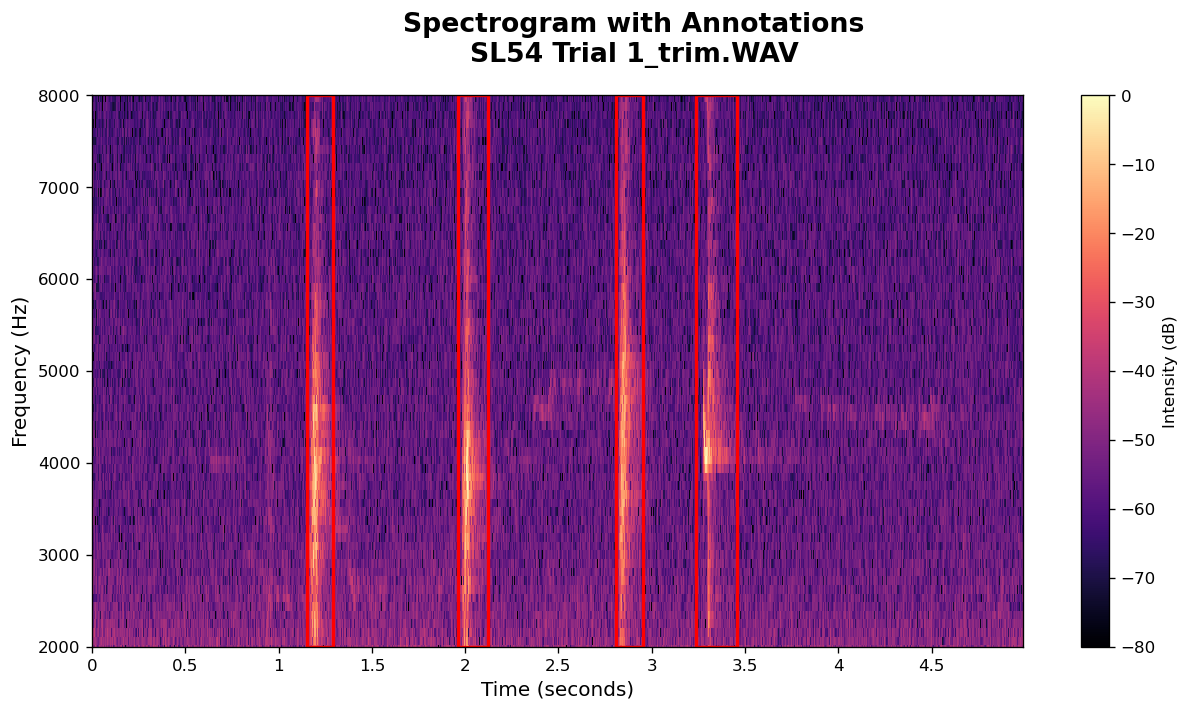


=== Visualization complete! ===


In [16]:
# === VISUALIZE SPECTROGRAMS WITH BOUNDING BOXES FROM CSV ANNOTATIONS ===
# Raven-matched STFT settings + crisper rendering + fixed pixel output for YOLO-like clarity.
#
# Changes vs your current cell:
# - Keep true "zoom quality": we recompute STFT from the 5s audio (same as before).
# - Render without smoothing: shading="nearest", antialiased=False.
# - Use ONE frequency zoom method: ax.set_ylim(2000, 8000) (removed fmin/fmax from specshow).
# - Fixed pixel size output (useful for YOLO): set figsize from desired pixels + dpi.
# - Save a PNG at exactly that resolution so you can compare vs VS Code inline display.

import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import librosa
import librosa.display

# === LOAD THE CSV FILE ===
csv_path = "/home/Shelby/blackbird_calls/Dataset_processing/Datasets/cv4e_calls_channel1.csv"
annotations_df = pd.read_csv(csv_path)
print(f"Loaded {len(annotations_df)} annotations from CSV")

current_wav_fname = file_to_visualize
print(f"\nLooking for: {current_wav_fname}")

matching_annotations = annotations_df[annotations_df["wav_fname"] == current_wav_fname]
print(f"Exact match for '{current_wav_fname}': {len(matching_annotations)} annotations")

if len(matching_annotations) == 0:
    print("\nNo exact match found. Trying case-insensitive match...")
    matching_annotations = annotations_df[annotations_df["wav_fname"].str.lower() == current_wav_fname.lower()]
    print(f"Case-insensitive match: {len(matching_annotations)} annotations")

if len(matching_annotations) == 0:
    print("\nWARNING: Still no annotations found!")
else:
    # --- Fixed pixel sizing (helps avoid VS Code scaling blur and matches YOLO expectations) ---
    img_w_px, img_h_px = 1280, 720
    dpi = 120
    fig, ax = plt.subplots(figsize=(img_w_px / dpi, img_h_px / dpi), dpi=dpi)

    fig.suptitle(f"Spectrogram with Annotations\n{file_to_visualize}", fontsize=16, fontweight="bold")

    try:
        audio_path = os.path.join(trimmed_audio_dir, file_to_visualize)

        # Load audio without resampling; use channel 1 only if stereo
        y, sr = librosa.load(audio_path, sr=None, mono=False)
        if y.ndim > 1:
            y = y[0]

        # Trim to first 5 seconds
        duration_limit = 5
        y = y[: int(sr * duration_limit)]

        duration = librosa.get_duration(y=y, sr=sr)
        print(f"Audio duration: {duration:.2f} seconds")
        print(f"Sample rate: {sr} Hz\n")

        # --- Raven-matched STFT settings ---
        n_fft = 512
        win_length = 512
        hop_length = 128
        window = "hann"

        D = librosa.stft(
            y,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=win_length,
            window=window,
            center=False,
        )
        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

        # --- Display: crisp bin rendering (no smoothing) ---
        img = librosa.display.specshow(
            S_db,
            sr=sr,
            hop_length=hop_length,
            ax=ax,
            x_axis="time",
            y_axis="linear",
            shading="nearest",
            antialiased=False,
        )

        # --- Frequency zoom (use only ONE method for clarity) ---
        ax.set_ylim(2000, 8000)

        print("Spectrogram axis limits after display:")
        print(f"  X-axis (time): {ax.get_xlim()}")
        print(f"  Y-axis (Hz): {ax.get_ylim()}\n")

        time_max = duration_limit
        matching_annotations = matching_annotations[
            matching_annotations["begin_time_s"] < time_max
        ].copy()
        matching_annotations["end_time_s"] = matching_annotations["end_time_s"].clip(upper=time_max)

        f_lo, f_hi = 2000, 8000
        matching_annotations = matching_annotations[
            (matching_annotations["high_freq_hz"] > f_lo) & (matching_annotations["low_freq_hz"] < f_hi)
        ].copy()
        matching_annotations["low_freq_hz"] = matching_annotations["low_freq_hz"].clip(lower=f_lo)
        matching_annotations["high_freq_hz"] = matching_annotations["high_freq_hz"].clip(upper=f_hi)

        # === DRAW BOUNDING BOXES FROM ANNOTATIONS ===
        print(f"Drawing {len(matching_annotations)} bounding boxes...\n")
        print("\nAll annotations min/max:")
        print(f"  Time (seconds): {matching_annotations['begin_time_s'].min():.2f} - {matching_annotations['end_time_s'].max():.2f}")
        print(f"  Freq (Hz): {matching_annotations['low_freq_hz'].min():.0f} - {matching_annotations['high_freq_hz'].max():.0f}")

        box_count = 0
        for idx, (_, row) in enumerate(matching_annotations.iterrows()):
            time_start = float(row["begin_time_s"])
            time_end = float(row["end_time_s"])
            freq_low_hz = float(row["low_freq_hz"])
            freq_high_hz = float(row["high_freq_hz"])

            if idx < 10:
                print(f"Annotation {idx + 1}:")
                print(f"  Time: {time_start:.2f}-{time_end:.2f}s")
                print(f"  Freq (Hz): {freq_low_hz:.0f}-{freq_high_hz:.0f}")

            rect = Rectangle(
                (time_start, freq_low_hz),
                time_end - time_start,
                freq_high_hz - freq_low_hz,
                linewidth=2,
                edgecolor="red",
                facecolor="none",
            )
            ax.add_patch(rect)
            box_count += 1

        print(f"\nAdded {box_count} rectangles to the plot")

        plt.colorbar(img, ax=ax, label="Intensity (dB)")
        ax.set_xlabel("Time (seconds)", fontsize=12)
        ax.set_ylabel("Frequency (Hz)", fontsize=12)

        # Save a PNG at the fixed pixel size to compare against inline display
        out_png_fname = f"{Path(file_to_visualize).stem}_spec_{img_w_px}x{img_h_px}.png"
        plt.savefig(out_png_fname, dpi=dpi, bbox_inches="tight", pad_inches=0.05)
        print(f"Saved spectrogram PNG to: {out_png_fname}")

        print(f"✓ Spectrogram with {len(matching_annotations)} annotations created successfully")

    except Exception as e:
        print(f"✗ Error: {str(e)}")
        import traceback

        traceback.print_exc()

    plt.tight_layout()
    plt.savefig("hop_shortened.jpg")
    plt.show()

    print("\n=== Visualization complete! ===")


Drawing bounding boxes- increasing fft and window length / frequency detail, clean

Saved clean spectrogram to: SL54 Trial 1_trim_spec_clean.png


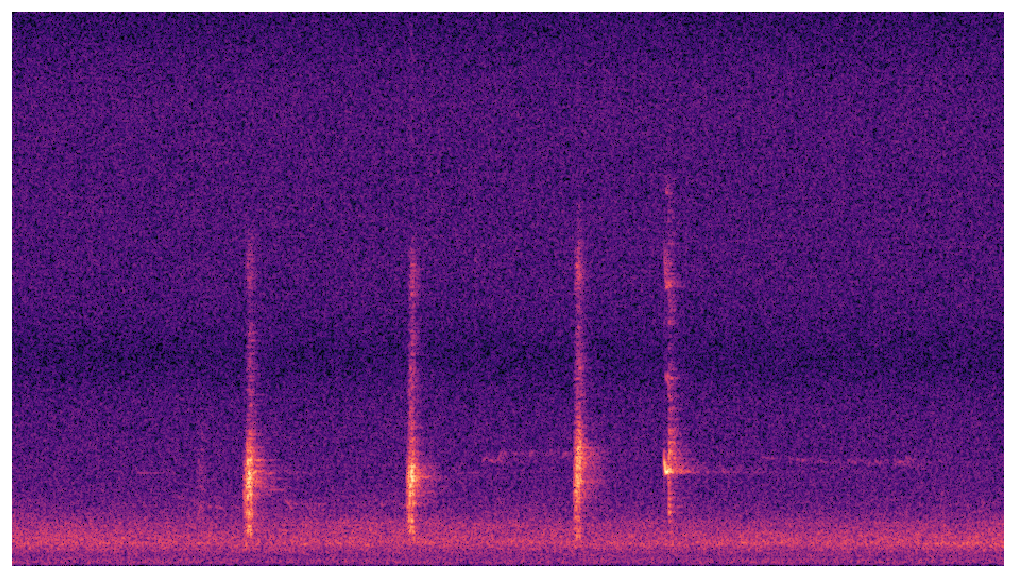

In [17]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import librosa
import librosa.display

csv_path = "/home/Shelby/blackbird_calls/Dataset_processing/Datasets/cv4e_calls_channel1.csv"
annotations_df = pd.read_csv(csv_path)

current_wav_fname = file_to_visualize
matching_annotations = annotations_df[annotations_df["wav_fname"] == current_wav_fname]

if len(matching_annotations) == 0:
    matching_annotations = annotations_df[annotations_df["wav_fname"].str.lower() == current_wav_fname.lower()]

if len(matching_annotations) > 0:
    img_w_px, img_h_px = 1280, 720
    dpi = 120
    fig, ax = plt.subplots(figsize=(img_w_px / dpi, img_h_px / dpi), dpi=dpi)

    try:
        audio_path = os.path.join(trimmed_audio_dir, file_to_visualize)
        y, sr = librosa.load(audio_path, sr=None, mono=False)
        if y.ndim > 1:
            y = y[0]

        duration_limit = 5
        y = y[: int(sr * duration_limit)]

        n_fft = 1024
        win_length = 1024
        hop_length = 256
        window = "hann"

        D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, win_length=win_length, window=window, center=False)
        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

        img = librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, ax=ax, x_axis="off", y_axis="off", shading="nearest", antialiased=False)

        ax.axis('off')  # Hide all axes and labels
        
        out_png_fname = f"{Path(file_to_visualize).stem}_spec_clean.png"
        plt.savefig(out_png_fname, dpi=dpi, bbox_inches="tight", pad_inches=0)
        print(f"Saved clean spectrogram to: {out_png_fname}")

    except Exception as e:
        print(f"✗ Error: {str(e)}")

    plt.show()


Testing putting on the bounding boxes to this generated image again

Drawing 4 bounding boxes...

Call type color mapping:
  B: red (1 boxes)
  Check: blue (3 boxes)

Saved spectrogram with boxes to: SL54_Trial_1_trim_spec_with_boxes.png


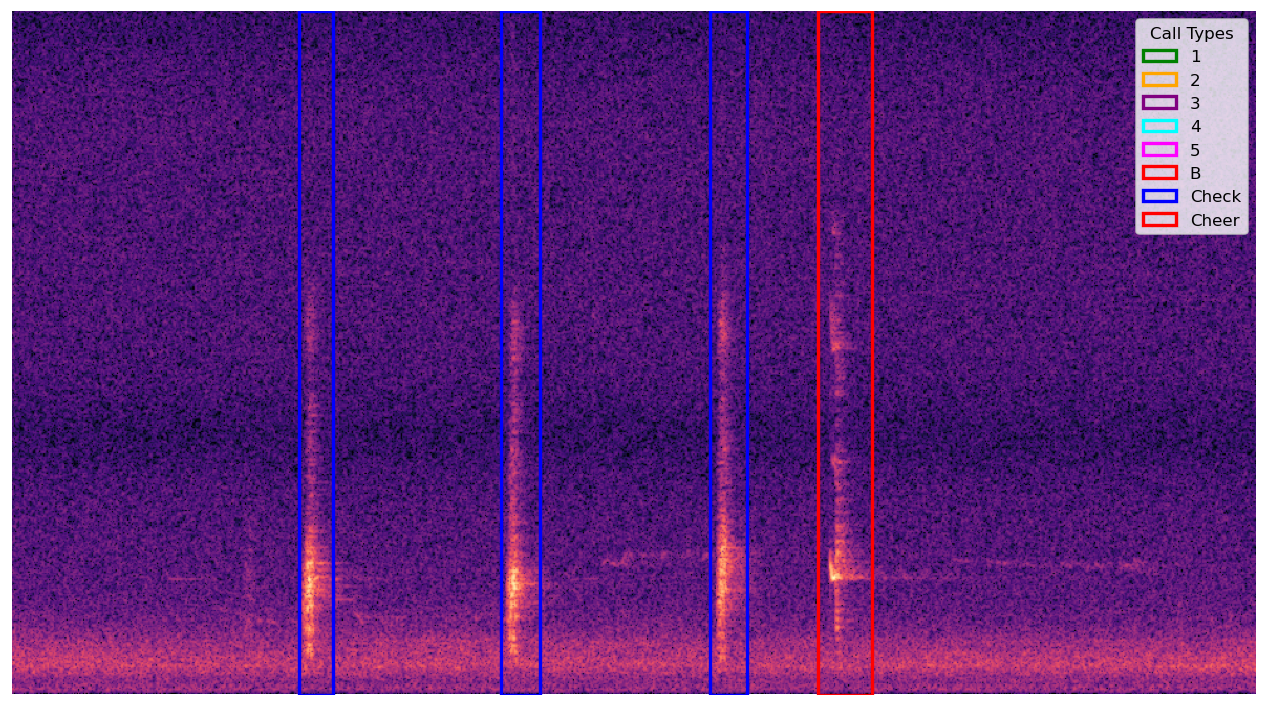

In [19]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

# === LOAD THE SAVED SPECTROGRAM IMAGE ===
image_path = "/home/Shelby/blackbird_calls/Dataset_processing/Datasets/SL54 Trial 1_trim_spec_clean.png"

if not os.path.exists(image_path):
    print(f"Error: Image not found at {image_path}")
else:
    # Load the image
    img_pil = Image.open(image_path)
    img_array = np.array(img_pil)
    
    # === LOAD THE CSV ANNOTATIONS ===
    csv_path = "/home/Shelby/blackbird_calls/Dataset_processing/Datasets/cv4e_calls_channel1_v2.csv"
    annotations_df = pd.read_csv(csv_path)
    
    # Match annotations to the file
    matching_annotations = annotations_df[annotations_df["wav_fname"] == "SL54 Trial 1_trim.WAV"]
    
    if len(matching_annotations) == 0:
        matching_annotations = annotations_df[annotations_df["wav_fname"].str.lower() == "sl54 trial 1_trim.wav"]
    
    if len(matching_annotations) > 0:
        # Create figure with the image
        img_w_px, img_h_px = 1280, 720
        dpi = 120
        fig, ax = plt.subplots(figsize=(img_w_px / dpi, img_h_px / dpi), dpi=dpi)
        
        # Display the image
        ax.imshow(img_array, aspect='auto', origin='upper')
        ax.set_xlim(0, img_array.shape[1])
        ax.set_ylim(img_array.shape[0], 0)
        
        # === FILTER ANNOTATIONS TO MATCH IMAGE ===
        time_max = 5  # Match your 5-second limit
        matching_annotations = matching_annotations[
            matching_annotations["begin_time_s"] < time_max
        ].copy()
        matching_annotations["end_time_s"] = matching_annotations["end_time_s"].clip(upper=time_max)
        
        f_lo, f_hi = 2000, 8000
        matching_annotations = matching_annotations[
            (matching_annotations["high_freq_hz"] > f_lo) & (matching_annotations["low_freq_hz"] < f_hi)
        ].copy()
        matching_annotations["low_freq_hz"] = matching_annotations["low_freq_hz"].clip(lower=f_lo)
        matching_annotations["high_freq_hz"] = matching_annotations["high_freq_hz"].clip(upper=f_hi)
        
                # === MAP TIME/FREQ COORDINATES TO PIXEL COORDINATES ===
        time_range = (0, time_max)  # seconds
        freq_range = (f_lo, f_hi)  # Hz
        
        # Convert data coordinates to pixel coordinates
        def data_to_pixels(time_s, freq_hz):
            # Linear mapping from data space to pixel space
            x_px = (time_s - time_range[0]) / (time_range[1] - time_range[0]) * img_array.shape[1]
            y_px = (freq_hz - freq_range[0]) / (freq_range[1] - freq_range[0]) * img_array.shape[0]
            return x_px, y_px
        
        # === DEFINE COLOR MAPPING FOR CALL TYPES ===
        call_type_colors = {
            "Cheer": "red",
            "Check": "blue",
            "1": "green",
            "2": "orange",
            "3": "purple",
            "4": "cyan",
            "5": "magenta",
        }
        
        # Get unique call types and assign colors to any unmapped ones
        unique_call_types = matching_annotations["call_type"].unique()
        colors_list = ["red", "blue", "green", "orange", "purple", "cyan", "magenta", "yellow", "brown", "pink"]
        color_idx = 0
        for call_type in unique_call_types:
            if call_type not in call_type_colors:
                call_type_colors[call_type] = colors_list[color_idx % len(colors_list)]
                color_idx += 1
        
        # === DRAW BOUNDING BOXES ===
        print(f"Drawing {len(matching_annotations)} bounding boxes...\n")
        print("Call type color mapping:")
        for call_type, color in sorted(call_type_colors.items()):
            count = len(matching_annotations[matching_annotations["call_type"] == call_type])
            if count > 0:
                print(f"  {call_type}: {color} ({count} boxes)")
        print()

        for idx, (_, row) in enumerate(matching_annotations.iterrows()):
            time_start = float(row["begin_time_s"])
            time_end = float(row["end_time_s"])
            freq_low_hz = float(row["low_freq_hz"])
            freq_high_hz = float(row["high_freq_hz"])
            call_type = str(row["call_type"])  # Extract the call_type
    
            # Get the color for this call type
            box_color = call_type_colors.get(call_type, "gray")
            
            # Convert to pixel coordinates
            x_start_px, y_high_px = data_to_pixels(time_start, freq_high_hz)  # Top-left
            x_end_px, y_low_px = data_to_pixels(time_end, freq_low_hz)  # Bottom-right
            
            width_px = x_end_px - x_start_px
            height_px = y_low_px - y_high_px
            
            rect = Rectangle(
                (x_start_px, y_high_px),
                width_px,
                height_px,
                linewidth=2,
                edgecolor=box_color,  # Use the color based on call_type
                facecolor="none",
            )
            ax.add_patch(rect)

        # === CREATE LEGEND ===
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='none', edgecolor=color, linewidth=2, label=call_type)
                        for call_type, color in sorted(call_type_colors.items())]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=10, title='Call Types')
        
        ax.axis('off')  # Keep axes off like the original
        
        out_png_fname = "SL54_Trial_1_trim_spec_with_boxes.png"
        plt.savefig(out_png_fname, dpi=dpi, bbox_inches="tight", pad_inches=0)
        print(f"Saved spectrogram with boxes to: {out_png_fname}")
        
        plt.tight_layout()
        plt.show()
    else:
        print("No matching annotations found for this audio file")

Visualizing spectrogram again but using txt labels from labels folder


Looking for image: /home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/YOLO_v1/images/AZ02_Trial_1_trim_spec_15-20.png
Looking for labels: /home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/YOLO_v1/labels/AZ02_Trial_1_trim_spec_15-20.txt

Loaded 9 annotations from YOLO label file
Image dimensions: 991 x 554 pixels

Drawing 9 bounding boxes from YOLO labels...

Annotations by call type:
  A: green (2 boxes)
  Check: blue (5 boxes)
  Cheer: red (2 boxes)

Box 1: A
  Center: (41.3, 309.6) px
  Size: 76.5 x 311.6 px
Box 2: Check
  Center: (246.5, 415.2) px
  Size: 20.1 x 182.8 px
Box 3: Check
  Center: (282.9, 472.7) px
  Size: 22.8 x 106.1 px
Box 4: Cheer
  Center: (421.6, 272.8) px
  Size: 140.3 x 401.8 px
Box 5: Check
  Center: (585.4, 403.7) px
  Size: 28.9 x 228.0 px


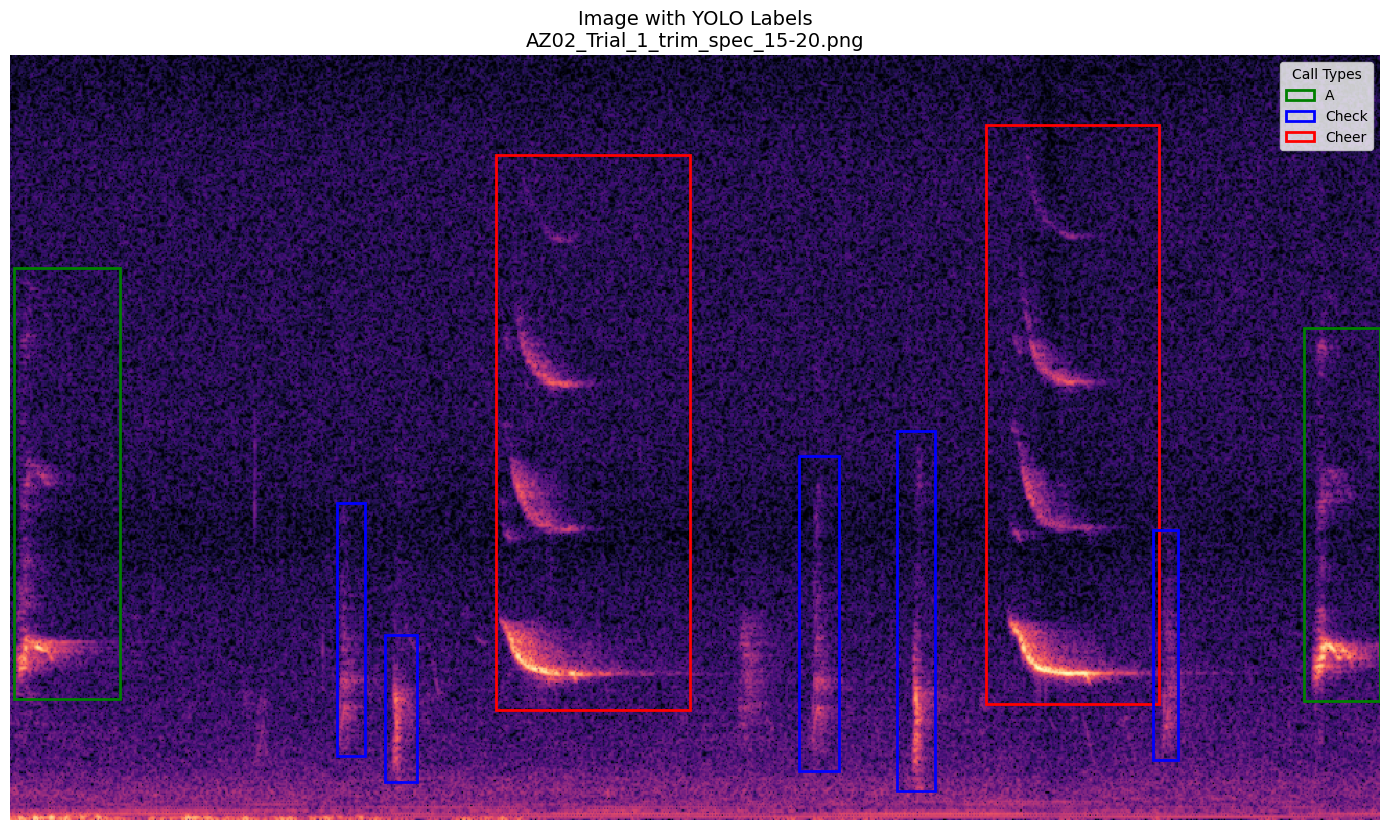


✓ Successfully visualized image with 9 YOLO label boxes


In [2]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

# === CONFIGURATION ===
images_dir = '/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/YOLO_v1/images'
labels_dir = '/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/YOLO_v1/labels'

# === GET USER INPUT FOR IMAGE NAME ===
image_name = input("Enter the image filename to visualize: ").strip()

# Reverse class mapping (from class number to call type name)
class_names = {
    0: 'Check',
    1: 'Cheer',
    2: 'Chits',
    3: 'Growl',
    4: 'A',
    5: 'B',
    6: 'C',
    7: 'D',
    8: 'E',
    9: 'F',
    10: 'G',
    11: 'H',
    12: 'I',
    13: 'J',
    14: 'K',
    15: 'O'
}

# Define color mapping for call types
call_type_colors = {
    "Cheer": "red",
    "Check": "blue",
    "Chits": "cyan",
    "Growl": "purple",
    "A": "green",
    "B": "orange",
    "C": "magenta",
    "D": "yellow",
    "E": "pink",
    "F": "lime",
    "G": "brown",
    "H": "olive",
    "I": "navy",
    "J": "teal",
    "K": "gold",
    "O": "coral"
}

# === LOAD IMAGE AND LABELS ===
image_path = os.path.join(images_dir, image_name)
label_filename = Path(image_name).stem + '.txt'
label_path = os.path.join(labels_dir, label_filename)

print(f"\nLooking for image: {image_path}")
print(f"Looking for labels: {label_path}")

if not os.path.exists(image_path):
    print(f"\nERROR: Image file not found!")
elif not os.path.exists(label_path):
    print(f"\nWARNING: Label file not found! Will display image without annotations.")
    # Display image without annotations
    img_pil = Image.open(image_path)
    img_array = np.array(img_pil)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img_array)
    ax.set_title(f"Image: {image_name}\n(No annotations found)", fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    # === READ YOLO LABELS ===
    annotations = []
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                class_num = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])
                
                call_type = class_names.get(class_num, f"Unknown_{class_num}")
                
                annotations.append({
                    'class': class_num,
                    'call_type': call_type,
                    'x_center': x_center,
                    'y_center': y_center,
                    'width': width,
                    'height': height
                })
    
    print(f"\nLoaded {len(annotations)} annotations from YOLO label file")
    
    # === LOAD AND DISPLAY IMAGE ===
    img_pil = Image.open(image_path)
    img_array = np.array(img_pil)
    img_h, img_w = img_array.shape[:2]
    
    print(f"Image dimensions: {img_w} x {img_h} pixels")
    
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.imshow(img_array)
    ax.set_xlim(0, img_w)
    ax.set_ylim(img_h, 0)
    
    # === DRAW BOUNDING BOXES ===
    print(f"\nDrawing {len(annotations)} bounding boxes from YOLO labels...\n")
    
    # Count annotations by call type
    call_type_counts = {}
    for ann in annotations:
        ct = ann['call_type']
        call_type_counts[ct] = call_type_counts.get(ct, 0) + 1
    
    print("Annotations by call type:")
    for call_type, count in sorted(call_type_counts.items()):
        color = call_type_colors.get(call_type, "gray")
        print(f"  {call_type}: {color} ({count} boxes)")
    print()
    
    for idx, ann in enumerate(annotations):
        call_type = ann['call_type']
        box_color = call_type_colors.get(call_type, "gray")
        
        # Convert YOLO normalized coordinates to pixel coordinates
        x_center_px = ann['x_center'] * img_w
        y_center_px = ann['y_center'] * img_h
        width_px = ann['width'] * img_w
        height_px = ann['height'] * img_h
        
        # Calculate top-left corner for Rectangle
        x_topleft = x_center_px - width_px / 2
        y_topleft = y_center_px - height_px / 2
        
        if idx < 5:  # Print first 5 for verification
            print(f"Box {idx+1}: {call_type}")
            print(f"  Center: ({x_center_px:.1f}, {y_center_px:.1f}) px")
            print(f"  Size: {width_px:.1f} x {height_px:.1f} px")
        
        rect = Rectangle(
            (x_topleft, y_topleft),
            width_px,
            height_px,
            linewidth=2,
            edgecolor=box_color,
            facecolor="none",
        )
        ax.add_patch(rect)
    
    # === CREATE LEGEND ===
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='none', edgecolor=call_type_colors.get(ct, 'gray'), 
                            linewidth=2, label=ct)
                      for ct in sorted(call_type_counts.keys())]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10, title='Call Types')
    
    ax.set_title(f"Image with YOLO Labels\n{image_name}", fontsize=14)
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Successfully visualized image with {len(annotations)} YOLO label boxes")